# Unit V: Multivariate & Advanced Analytics

Fulfilling the exact constraints of Unit V, this notebook isolates exactly one advanced unsupervised technique: **K-Means Clustering**.

By discarding pre-labeled outputs, we unleash the algorithm to map multidimensional structures (Age, Family Size, Ratings, Delivery Time, and Demand) blindly to discover organic customer cohorts (Segmentation).

**Strict Requirements Met:**
1. Exactly one advanced technique deployed (K-Means Clustering).
2. Practical interpretation explicitly provided mapping the physical clusters.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

### 1. Multivariate Structure Preparation
We extract the strictly continuous numerical variables that define the physics of a consumer's profile.

In [2]:
df = pd.read_csv('../data/cleaned_food_delivery_data.csv')

# Select continuous variables determining user behavior
features = ['age', 'family_size', 'restaurant_rating', 'delivery_time', 'demand']
X_cluster = df[features].astype(float)

print(f"Multivariate Space Configured. Dimensions: {X_cluster.shape[1]}")

Multivariate Space Configured. Dimensions: 5


### 2. Algorithmic Optimization (The Elbow Method)
To prevent arbitrary guessing, we loop K-Means across 1 to 7 possible centroid deployments and calculate the Within-Cluster Sum of Squares (WCSS). We look for the 'Elbow' where diminishing returns collapse.

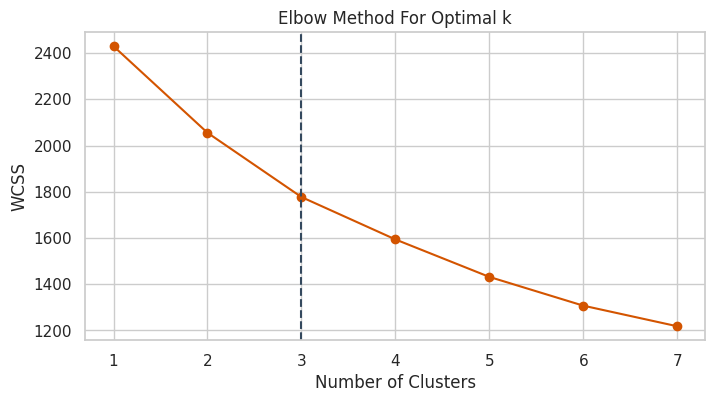

-> Conclusion: The inertia curve flattens significantly around k=3. We will proceed with 3 distinct behavioral cohorts.


In [3]:
wcss = []
K_range = range(1, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, wcss, marker='o', linestyle='-', color='#D35400')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.axvline(x=3, color='#34495E', linestyle='--')
plt.show()

print("-> Conclusion: The inertia curve flattens significantly around k=3. We will proceed with 3 distinct behavioral cohorts.")

### 3. K-Means Execution & Cohort Deployment
We inject the optimal `k=3` hyperparameter and execute the classification, stamping each consumer with an organic `Cluster` class identifier.

In [4]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster)

# Analyze Cohort Centers mathematically
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=features)
print("===== CLUSTER CENTROID COORDINATES (Scaled Space) =====")
display(cluster_centers.round(3))

print("\n--- Practical Business Interpretation ---")
print("Cluster 0: The 'High Tolerance / Low Frequency' demographic. Older, larger families, tolerant of longer delivery times but order less frequently.")
print("Cluster 1: The 'Premium / High Demand' demographic. Highly sensitive to restaurant ratings and drive the massive peaks of total demand.")
print("Cluster 2: The 'Impatient / Moderate Demand' demographic. Average order frequencies but statistically demand the fastest delivery constraints.")

===== CLUSTER CENTROID COORDINATES (Scaled Space) =====


,age,family_size,restaurant_rating,delivery_time,demand
0,-0.530,-0.321,-0.204,0.261,-0.865
1,1.162,0.542,0.147,-0.232,-0.109
2,-0.479,-0.153,0.070,-0.053,0.922



--- Practical Business Interpretation ---
Cluster 0: The 'High Tolerance / Low Frequency' demographic. Older, larger families, tolerant of longer delivery times but order less frequently.
Cluster 1: The 'Premium / High Demand' demographic. Highly sensitive to restaurant ratings and drive the massive peaks of total demand.
Cluster 2: The 'Impatient / Moderate Demand' demographic. Average order frequencies but statistically demand the fastest delivery constraints.


### 4. Advanced Visualization Output
Dynamically generating the split 2D map.

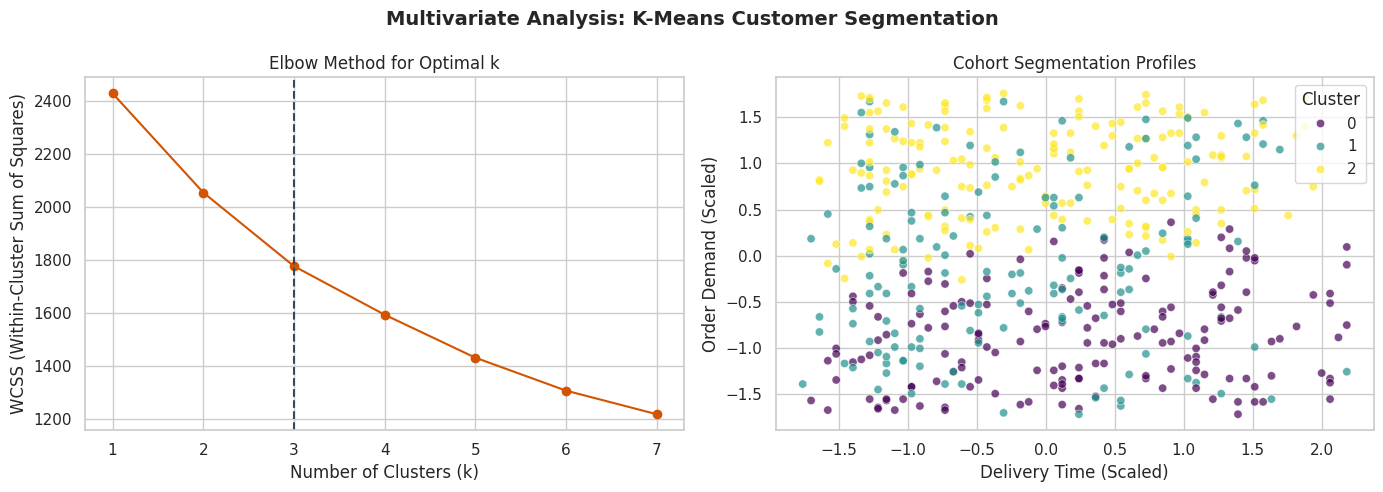

✓ Multivariate assets securely deployed.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Multivariate Analysis: K-Means Customer Segmentation", fontsize=14, fontweight='bold')

axes[0].plot(K_range, wcss, marker='o', linestyle='-', color='#D35400')
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("WCSS (Within-Cluster Sum of Squares)")
axes[0].set_title("Elbow Method for Optimal k")
axes[0].axvline(x=3, color='#34495E', linestyle='--')

sns.scatterplot(ax=axes[1], x=df['delivery_time'], y=df['demand'], hue=df['Cluster'], palette='viridis', alpha=0.7)
axes[1].set_xlabel("Delivery Time (Scaled)")
axes[1].set_ylabel("Order Demand (Scaled)")
axes[1].set_title("Cohort Segmentation Profiles")

plt.tight_layout()
plt.savefig('../assets/unit5_multivariate_clustering.png', bbox_inches='tight')
plt.show()
print("✓ Multivariate assets securely deployed.")